### Fundamentos de Linguagem Python - Do Básico a Aplicações de IA
### Mini-Projeto 1
### Análise de Vendas Para Loja de E-commerce com NumPy, Pandas e Matplotlib

## 1. Definição do Problema de Negócio

**1.1. O Problema de Negócio**

Nossa loja de e-commerce está em fase de crescimento, registrando um volume cada vez maior de transações diárias. No entanto, essa grande quantidade de dados de vendas, em seu estado bruto, é como um baú de tesouro trancado: sabemos que há valor ali, mas não conseguimos acessá-lo.

Atualmente, muitas de nossas decisões estratégicas são baseadas em intuição e observações parciais, o que nos leva a enfrentar os seguintes desafios:

- Gestão de Estoque Ineficiente: Não temos clareza sobre quais produtos são nossos "campeões de venda" e quais estão parados nas prateleiras. Isso resulta em excesso de estoque de itens de baixa procura e falta de produtos de alta demanda.

- Marketing com Baixo Retorno: Nossas campanhas de marketing são genéricas, pois não sabemos quais categorias de produtos atraem mais os clientes ou em quais regiões geográficas nosso público está mais concentrado.

- Perda de Oportunidades Sazonais: Não conseguimos identificar padrões ou tendências de vendas ao longo dos meses. Isso nos impede de planejar promoções estratégicas para períodos de alta ou de criar ações para impulsionar as vendas em meses de baixa.

- Expansão sem Direção: Temos o desejo de expandir, mas não sabemos quais mercados regionais são mais promissores ou onde nossos esforços logísticos deveriam ser focados.

O problema central é a falta de visibilidade clara sobre a performance do negócio, o que nos impede de tomar decisões rápidas, inteligentes e baseadas em evidências.

**1.2. Objetivos do Projeto**

Este projeto de análise de dados visa transformar nossos dados brutos de vendas em insights acionáveis. O objetivo é responder a quatro perguntas de negócio fundamentais:

- O que vender? Identificar os produtos de maior sucesso para otimizar nosso portfólio e estoque.
<!-- Trabalho Desenvolvido no Curso da Data Science Academy - www.datascienceacademy.com.br -->
- Onde focar? Compreender quais categorias de produtos geram a maior parte da nossa receita.

- Quando agir? Analisar a performance de vendas ao longo do tempo para identificar tendências, picos e sazonalidades.

- Para onde expandir? Mapear a distribuição geográfica de nossas vendas para descobrir nossos mercados mais fortes.

**1.3. Solução Proposta**

A solução consiste em consolidar, limpar e analisar o histórico de dados de vendas da nossa plataforma. Utilizando ferramentas de análise de dados (como Python com Pandas, NumPy e Matplotlib), vamos processar essas informações e criar um relatório visual que apresente as descobertas de forma clara e intuitiva para as equipes de gestão, marketing e operações.

**1.4. Resultados Esperados e Benefícios de Negócio**

Ao final deste projeto, esperamos alcançar os seguintes resultados:

- Otimização de Estoque: Com a lista dos produtos mais e menos vendidos, poderemos ajustar nossas compras, reduzir custos com armazenamento e evitar a perda de vendas por falta de produto.

- Marketing Direcionado e Eficaz: Sabendo quais categorias e regiões são mais lucrativas, a equipe de marketing poderá criar campanhas segmentadas, aumentando o retorno sobre o investimento (ROI).

- Planejamento Estratégico: A visualização das tendências mensais permitirá um melhor planejamento financeiro, promocional e de recursos, antecipando períodos de alta e baixa demanda.

- Decisões Baseadas em Dados: Substituiremos a intuição por dados concretos, criando uma cultura orientada a dados que impulsionará o crescimento sustentável do negócio.

## 2. Importação das Bibliotecas

In [2]:
!pip install -q -U watermark

In [3]:
#Importando biblioteca para manipulação de dados
import pandas as pd

#Importando biblioteca para operações matemáticas e arrays
import numpy as np

#Importando biblioteca Matplotlib para plotar gráficos
import matplotlib.pyplot as plt

#Importando a biblioteca Seaborn para visualização estatísticas de dados
import seaborn as sns

#IMportando a biblioteca random para geração de números aleatórios
import random

#Importando as classes datetime e timedelta, para manipulação de datas e intervalo de tempo
from datetime import datetime, timedelta

#Comando para o jupyter notebook plotar gráficos
%matplotlib inline

In [5]:
%reload_ext watermark
%watermark -a "Sávio Giovani - SG"

Author: Sávio Giovani - SG



In [6]:
%watermark --iversions

matplotlib: 3.10.0
numpy     : 2.3.2
pandas    : 2.3.2
seaborn   : 0.13.2



In [ ]:
#para instalar uma versão específica de um pacote podemos fazer:
!pip install -q pandas==2.3.1

## 3.Função para geração de dados fictícios

In [18]:
#Definição da função para gerar dados fictícios de exempolo
def sg_gera_dados_ficticios(num_registros = 600):
    """
    Gera dataframe do pandas com dados ficticios
    """
    #Mensagem inicial indicando a quantidade de registros a serem gerados
    print(f"\nIniciando a geração {num_registros} registros de vendas ...")

    #Dicionário de produtos
    produtos = {
        'Notebook Gamer' : {'categoria': 'Eletrônicos','preco': 7500.00},
        'Mouse Gamer' : {'categoria':'Periféricos','preco': 250.00},
        'Teclado Magnético' : {'categoria':'Periféricos','preco':550.00},
        'Monitor 320Hz' : {'categoria':'Eletrônicos','preco':2800.00},
        'Headset' : {'categoria':'Periféricos','preco':1200.00},
        'Placa de Vídeo' : {'categoria':'Hardware','preco':4500.00},
        'SSD 1TB' : {'categoria':'Hardware','preco':600.00}
    }
 
    #Cria lista de produtos apenas com os nomes dos produtos
    lista_produtos = list(produtos.keys())

    #Dicionarios com cidades e seus respectivos estados
    cidades_estados = {
        'São Paulo' : 'SP', 'Rio de Janeiro':'RJ', 'Recife':'PE', 'Belo Horizonte':'MG',
        'Porto Alegre': 'RS', 'Salvador': 'BA', 'Curitiba':'PR', 'Fortaleza': 'CE'
    
    }
        #Cria uma lista apenas com os nomes das cidades
    lista_cidades = list(cidades_estados.keys())

    #Lista que armazenara os registros de vendas
    dados_vendas = []

    #define a data inicial do pedidos
    data_inicial = datetime(2026,1,1)

    #Loop para gerar os registros de vendas
    for i in range(num_registros):

        #Seleciona aleatoriamente um produto
        produtos_nome = random.choice(lista_produtos)

        #Seleciona aleatoriamente uma cidade
        cidade = random.choice(lista_cidades)

        #Gera uma quantidade de produtos vendidas entre 1 e 7
        quantidade = np.random.randint(1,8)

        #Calcula a data do pedido a partir da data inicial
        data_pedido = data_inicial + timedelta(days = int(i/5), hours = random.randint(0,23))

        #Se o produto for Mouse ou Teclado aplica desconto aleatorio de ate 10%
        if produtos_nome in ['Mouse Gamer','Teclado Magnético']:
            preco_unitario = produtos[produtos_nome]['preco'] * np.random.uniform(0.9,1.0)
        else:
            preco_unitario = produtos[produtos_nome]['preco']

        #Adiciona um registro de venda a lista
        dados_vendas.append({
            'ID Produto': 1000 + i,
            'Data_Pedido': data_pedido,
            'Nome_Produto': produtos_nome,
            'Categoria': produtos[produtos_nome]['categoria'],
            'Preco_Unitario': round(preco_unitario,2),
            'Quantidade': quantidade,
            'ID_Cliente': np.random.randint(100,150),
            'Cidade': cidade,
            'Estado': cidades_estados[cidade]
        })

        #Mensagem final
    print("Geração de Dados concluída\n")

        #Retorna os dados no formato de Dataframe
    return pd.DataFrame(dados_vendas)

## 4. Gerar, Carregar e Explorar os Dados


In [19]:
#Gera os dados chamando a funcao da celula anterior
df_vendas = sg_gera_dados_ficticios(500)


Iniciando a geração 500 registros de vendas ...
Geração de Dados concluída



In [20]:
type(df_vendas)

pandas.core.frame.DataFrame

In [21]:
#Shape
df_vendas.shape

(500, 9)

In [22]:
#Exibe as primeiras 5 linhas do DataFrame
df_vendas.head()

,ID Produto,Data_Pedido,Nome_Produto,Categoria,Preco_Unitario,Quantidade,ID_Cliente,Cidade,Estado
0,1000,2026-01-01 01:00:00,Notebook Gamer,Eletrônicos,7500.0,6,111,Fortaleza,CE
1,1001,2026-01-01 11:00:00,SSD 1TB,Hardware,600.0,1,120,Belo Horizonte,MG
2,1002,2026-01-01 14:00:00,Placa de Vídeo,Hardware,4500.0,4,106,Fortaleza,CE
3,1003,2026-01-01 12:00:00,Monitor 320Hz,Eletrônicos,2800.0,7,140,Fortaleza,CE
4,1004,2026-01-01 15:00:00,Placa de Vídeo,Hardware,4500.0,2,103,Porto Alegre,RS


In [23]:
#Exibe as ultimas 5 linhas do DataFrame
df_vendas.tail()

,ID Produto,Data_Pedido,Nome_Produto,Categoria,Preco_Unitario,Quantidade,ID_Cliente,Cidade,Estado
495,1495,2026-04-10 23:00:00,Teclado Magnético,Periféricos,527.27,5,148,Curitiba,PR
496,1496,2026-04-10 09:00:00,Notebook Gamer,Eletrônicos,7500.00,6,135,Fortaleza,CE
497,1497,2026-04-10 04:00:00,Monitor 320Hz,Eletrônicos,2800.00,4,114,São Paulo,SP
498,1498,2026-04-10 17:00:00,Mouse Gamer,Periféricos,244.46,4,122,Fortaleza,CE
499,1499,2026-04-10 02:00:00,Notebook Gamer,Eletrônicos,7500.00,6,119,Curitiba,PR


In [24]:
#Exibe informacoes gerais sobre o DataFrame(tipos de dados,valores nao nulos)
df_vendas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   ID Produto      500 non-null    int64         
 1   Data_Pedido     500 non-null    datetime64[ns]
 2   Nome_Produto    500 non-null    object        
 3   Categoria       500 non-null    object        
 4   Preco_Unitario  500 non-null    float64       
 5   Quantidade      500 non-null    int64         
 6   ID_Cliente      500 non-null    int64         
 7   Cidade          500 non-null    object        
 8   Estado          500 non-null    object        
dtypes: datetime64[ns](1), float64(1), int64(3), object(4)
memory usage: 35.3+ KB


In [25]:
#Resumo estatistico
df_vendas.describe()

,ID Produto,Data_Pedido,Preco_Unitario,Quantidade,ID_Cliente
count,500.000000,500,500.000000,500.000,500.000000
mean,1249.500000,2026-02-19 23:44:59.999999744,2630.015940,4.122,125.428000
min,1000.000000,2026-01-01 01:00:00,225.860000,1.000,100.000000
25%,1124.750000,2026-01-25 23:00:00,537.265000,2.000,114.000000
50%,1249.500000,2026-02-19 23:00:00,1200.000000,4.000,125.500000
75%,1374.250000,2026-03-16 23:30:00,4500.000000,6.000,138.000000
max,1499.000000,2026-04-10 23:00:00,7500.000000,7.000,149.000000
std,144.481833,NaN,2629.547588,1.948,14.409583


In [26]:
#Tipos de dados
df_vendas.dtypes

ID Produto                 int64
Data_Pedido       datetime64[ns]
Nome_Produto              object
Categoria                 object
Preco_Unitario           float64
Quantidade                 int64
ID_Cliente                 int64
Cidade                    object
Estado                    object
dtype: object

## 5. Limpeza, Pré-Processamento e Engenharia de Atributos

In [31]:
#Se a coluna 'Data_Pedido' não estiver como tipo datetime, precisamos fazer a conversão explícita
#A coluna pode ser usada para análise temporal
df_vendas['Data_Pedido'] = pd.to_datetime(df_vendas['Data_Pedido'])

In [32]:
#Engenharia de atributos
#Criando a coluna'Faturamento'(preco x quantidade)
df_vendas['Faturamento'] = df_vendas['Preco_Unitario'] * df_vendas['Quantidade']

In [33]:
#Engenharia de Atributos
#Usando uma funcao lambda para criar uma coluna de status de entrega
df_vendas['Status_Entrega'] = df_vendas['Estado'].apply(lambda estado: 'Rapida' if estado in ['SP','RJ','MG'] else 'Normal')

In [34]:
df_vendas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   ID Produto      500 non-null    int64         
 1   Data_Pedido     500 non-null    datetime64[ns]
 2   Nome_Produto    500 non-null    object        
 3   Categoria       500 non-null    object        
 4   Preco_Unitario  500 non-null    float64       
 5   Quantidade      500 non-null    int64         
 6   ID_Cliente      500 non-null    int64         
 7   Cidade          500 non-null    object        
 8   Estado          500 non-null    object        
 9   Faturamento     500 non-null    float64       
 10  Status_Entrega  500 non-null    object        
dtypes: datetime64[ns](1), float64(2), int64(3), object(5)
memory usage: 43.1+ KB


In [35]:
df_vendas.head()

,ID Produto,Data_Pedido,Nome_Produto,Categoria,Preco_Unitario,Quantidade,ID_Cliente,Cidade,Estado,Faturamento,Status_Entrega
0,1000,2026-01-01 01:00:00,Notebook Gamer,Eletrônicos,7500.0,6,111,Fortaleza,CE,45000.0,Normal
1,1001,2026-01-01 11:00:00,SSD 1TB,Hardware,600.0,1,120,Belo Horizonte,MG,600.0,Rapida
2,1002,2026-01-01 14:00:00,Placa de Vídeo,Hardware,4500.0,4,106,Fortaleza,CE,18000.0,Normal
3,1003,2026-01-01 12:00:00,Monitor 320Hz,Eletrônicos,2800.0,7,140,Fortaleza,CE,19600.0,Normal
4,1004,2026-01-01 15:00:00,Placa de Vídeo,Hardware,4500.0,2,103,Porto Alegre,RS,9000.0,Normal


## 6. Análise 1 - Top 10 Produtos Mais Vendidos
<!-- Trabalho Desenvolvido no Curso da Data Science Academy - www.datascienceacademy.com.br -->
Quais os top 10 produtos mais vendidos?

In [36]:
#para verificar o top10 produtos
top_10_produtos = df_vendas.groupby('Nome_Produto')['Quantidade'].sum().sort_values(ascending = False).head(10)

In [37]:
#exibe o resultado
top_10_produtos

Nome_Produto
Notebook Gamer       359
Headset              348
Mouse Gamer          311
Placa de Vídeo       282
Teclado Magnético    274
SSD 1TB              245
Monitor 320Hz        242
Name: Quantidade, dtype: int64

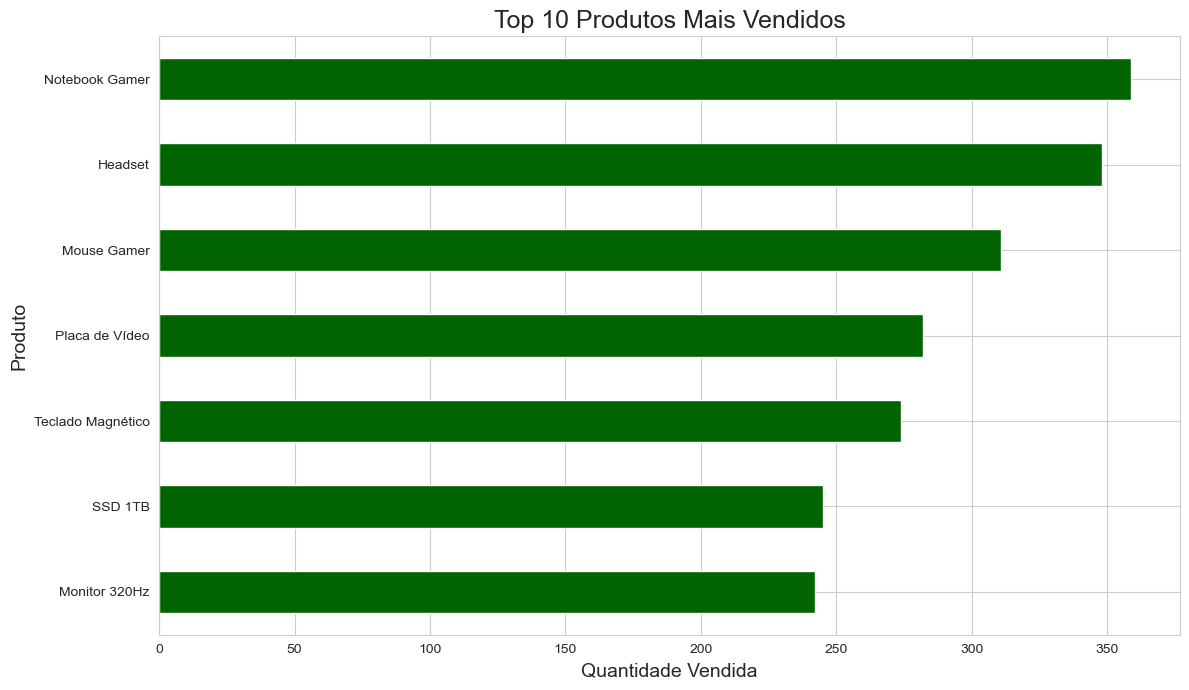

In [42]:
#Define um estilo para os graficos
sns.set_style("whitegrid")

#Cria a figura e os eixos
plt.figure(figsize=(12,7))

#Cria o grafico de barras horizontais
top_10_produtos.sort_values(ascending = True).plot(kind = 'barh', color = 'darkgreen')

#Adiciona titulos e labels
plt.title('Top 10 Produtos Mais Vendidos',fontsize = 18)
plt.xlabel('Quantidade Vendida',fontsize = 14)
plt.ylabel('Produto',fontsize = 14)

#Exibe o grafico
plt.tight_layout()
plt.show()

### 7.Analie 2 - Faturamento Mensal
Qual foi o faturamento mensal?

In [43]:
df_vendas.head()

,ID Produto,Data_Pedido,Nome_Produto,Categoria,Preco_Unitario,Quantidade,ID_Cliente,Cidade,Estado,Faturamento,Status_Entrega
0,1000,2026-01-01 01:00:00,Notebook Gamer,Eletrônicos,7500.0,6,111,Fortaleza,CE,45000.0,Normal
1,1001,2026-01-01 11:00:00,SSD 1TB,Hardware,600.0,1,120,Belo Horizonte,MG,600.0,Rapida
2,1002,2026-01-01 14:00:00,Placa de Vídeo,Hardware,4500.0,4,106,Fortaleza,CE,18000.0,Normal
3,1003,2026-01-01 12:00:00,Monitor 320Hz,Eletrônicos,2800.0,7,140,Fortaleza,CE,19600.0,Normal
4,1004,2026-01-01 15:00:00,Placa de Vídeo,Hardware,4500.0,2,103,Porto Alegre,RS,9000.0,Normal


In [46]:
#Cria uma coluna "Mes" para facilitar o agrupamento mensal
df_vendas['Mes'] = df_vendas['Data_Pedido'].dt.to_period('M')

In [47]:
df_vendas.head()

,ID Produto,Data_Pedido,Nome_Produto,Categoria,Preco_Unitario,Quantidade,ID_Cliente,Cidade,Estado,Faturamento,Status_Entrega,Mes
0,1000,2026-01-01 01:00:00,Notebook Gamer,Eletrônicos,7500.0,6,111,Fortaleza,CE,45000.0,Normal,2026-01
1,1001,2026-01-01 11:00:00,SSD 1TB,Hardware,600.0,1,120,Belo Horizonte,MG,600.0,Rapida,2026-01
2,1002,2026-01-01 14:00:00,Placa de Vídeo,Hardware,4500.0,4,106,Fortaleza,CE,18000.0,Normal,2026-01
3,1003,2026-01-01 12:00:00,Monitor 320Hz,Eletrônicos,2800.0,7,140,Fortaleza,CE,19600.0,Normal,2026-01
4,1004,2026-01-01 15:00:00,Placa de Vídeo,Hardware,4500.0,2,103,Porto Alegre,RS,9000.0,Normal,2026-01


In [52]:
#Agrupa por mês e soma o faturamento
faturamento_mensal = df_vendas.groupby('Mes')['Faturamento'].sum()

In [49]:
#Converte o indice para string para facilitar a plotagem no grafico
faturamento_mensal.index = faturamento_mensal.index.strftime('%Y-%m')

In [50]:
#Formata para duas casas decimais
faturamento_mensal.map('R${:.2f}'.format)

Mes
2026-01    R$1696816.57
2026-02    R$1371169.40
2026-03    R$1802937.59
2026-04     R$550908.80
Name: Faturamento, dtype: object

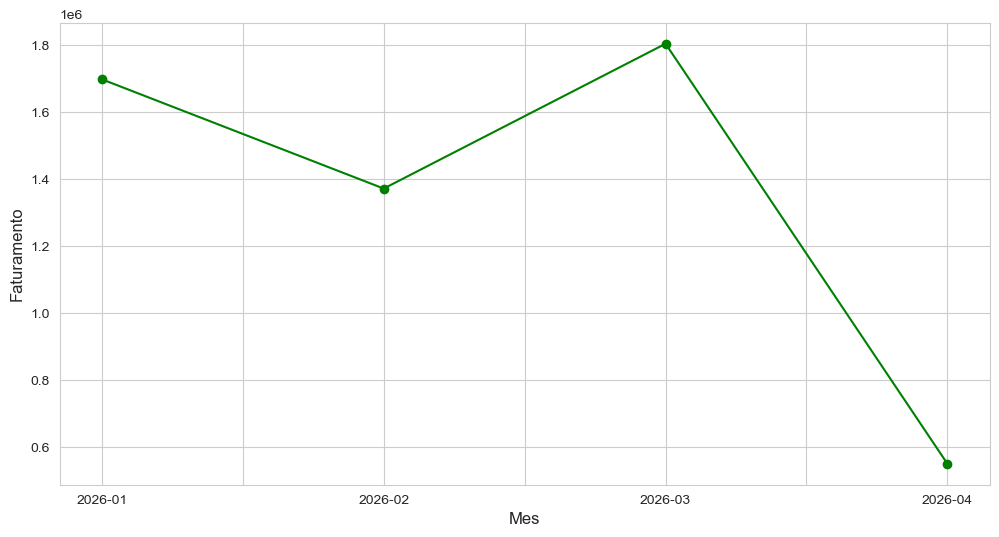

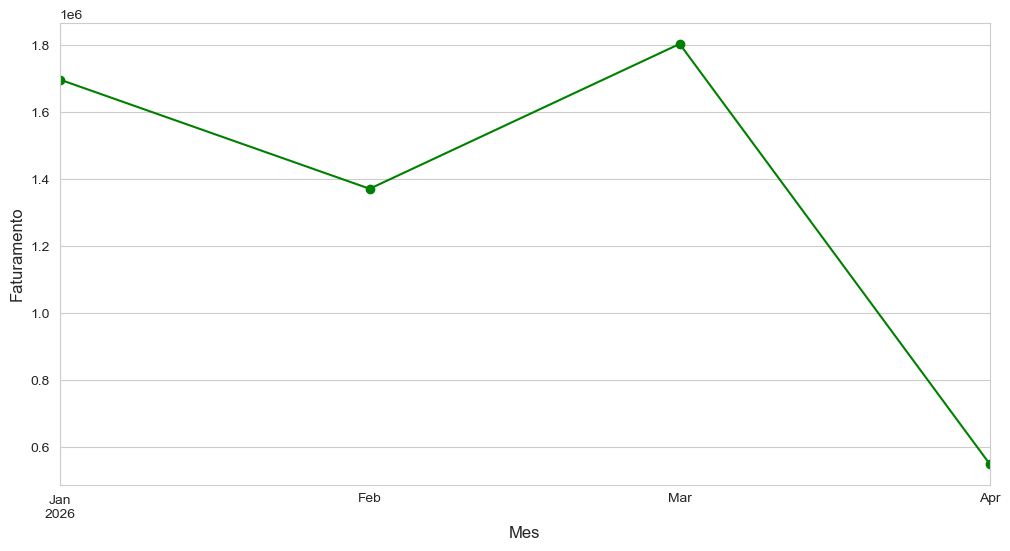

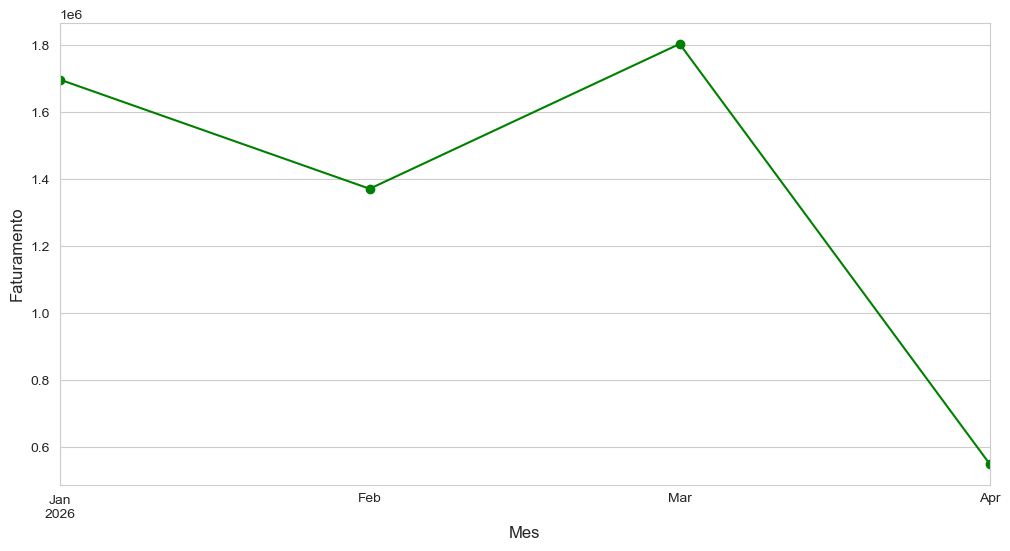

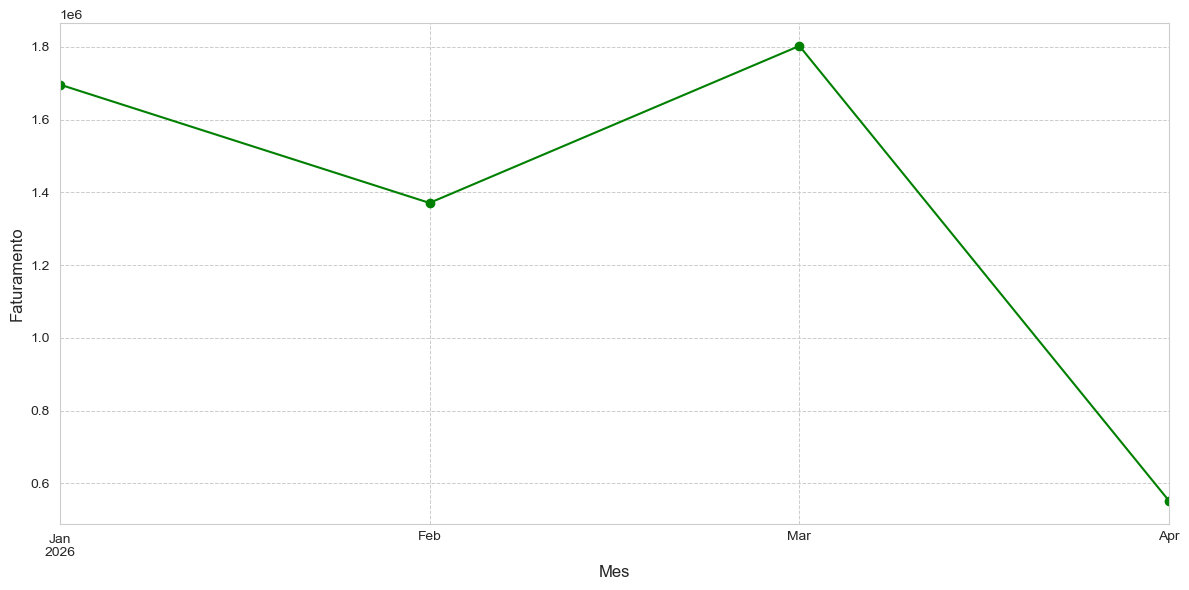

In [55]:
#Cria uma nova figura com tamanho 12 por 6 pol.
plt.figure(figsize =(12,6))

#Plota os dados do faturamento mensal em formato de linha
faturamento_mensal.plot(kind = 'line', marker = 'o', linestyle = '-', color = 'green')

#define o rotulo do eixo X
plt.xlabel('Mes', fontsize = 12)

#define o rotulo do eixo y
plt.ylabel('Faturamento', fontsize = 12)

#Rotaciona os valores do eixo x em 45 graus para melhor visualizacao
#plt.xticks(rotation = 45)

#Adiciona uma grade com estilo tracejado e linhas finas
plt.grid(True, which = 'both', linestyle = '--',linewidth = 0.7)

#Ajusta automaticamente os elementos para evitar sobreposicao
plt.tight_layout()

#PLota o grafico
plt.show()

## 8. Análise 3 - Vendas Por Estado

Qual o total de vendas por estado?

In [57]:
#Agrupa por estado e soma o faturamento
vendas_estado = df_vendas.groupby('Estado')['Faturamento'].sum().sort_values(ascending = False)

In [58]:
#Formata para duas casas decimais
vendas_estado.map('R${:,.2f}'.format)

Estado
SP    R$824,481.74
RS    R$763,343.81
PR    R$708,345.64
MG    R$694,893.70
RJ    R$653,840.28
CE    R$646,020.81
BA    R$633,671.15
PE    R$497,235.23
Name: Faturamento, dtype: object

<Figure size 1200x700 with 0 Axes>

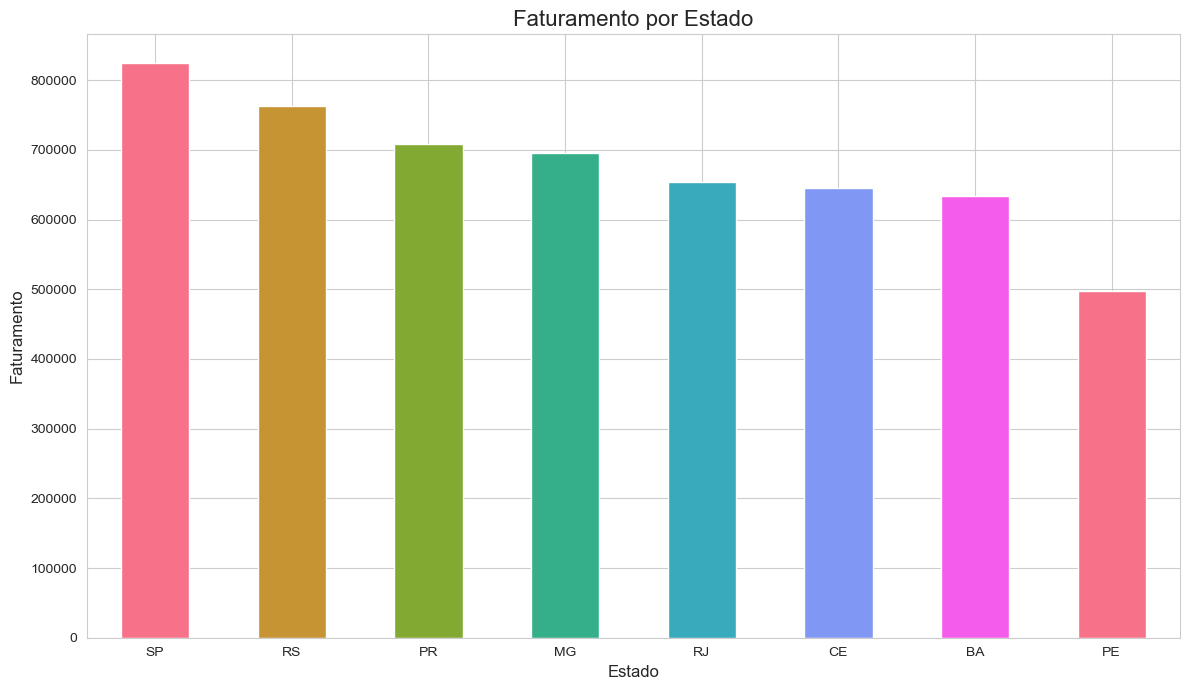

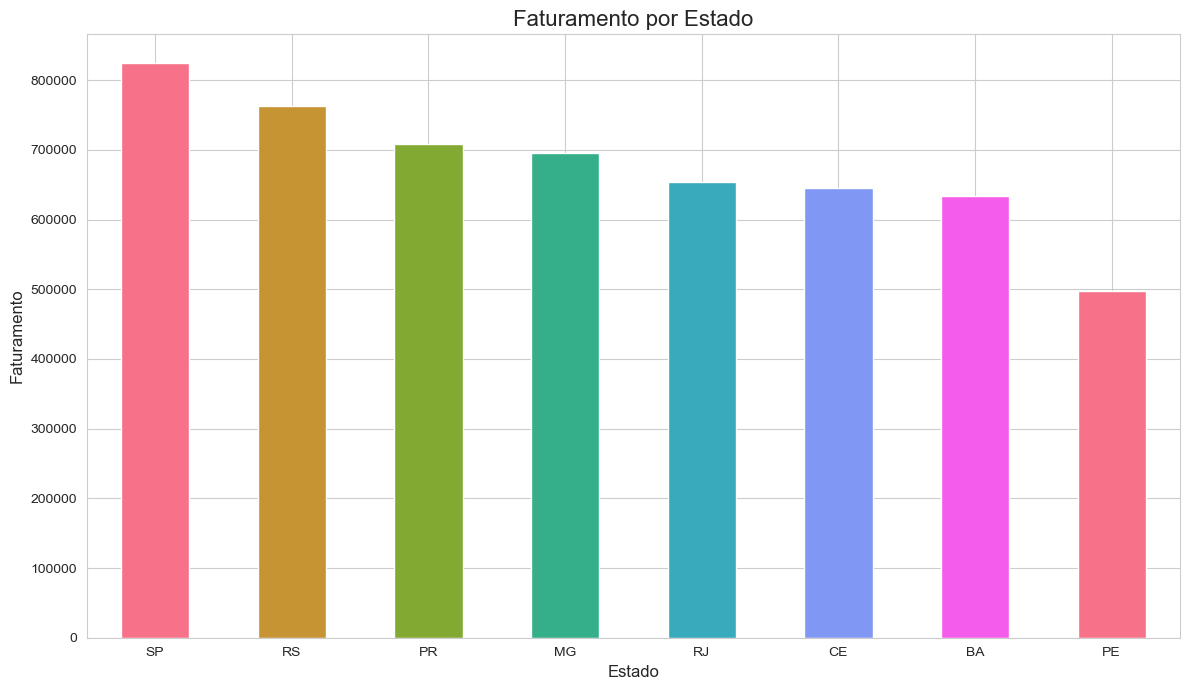

In [61]:
#Cria uma nova figura com tamanho de 12 por 7 pol
plt.figure(figsize = (12,7))

#Plota os dados de faturamento por estado em formato grafico de barras
#Usando a paleta de cores "Rocket" do Seaborn
vendas_estado.plot(kind = 'bar', color = sns.color_palette("husl",7))

#Define o titulo do grafico com fonte de tamanho 16
plt.title('Faturamento por Estado',fontsize = 16)

#Define o rotulo do eixo x
plt.xlabel('Estado',fontsize = 12)

#Define o rotulo do eixo y
plt.ylabel('Faturamento',fontsize = 12)

#mantem o rotulo do eixo x na horizontal padrao
plt.xticks(rotation = 0)

#Ajusta automaticamente os eementos do grafico para evitar sobreposicao
plt.tight_layout()

#Exibe o grafico
plt.show()

## 9. Análise 4 - Faturamento Por Categoria

Qual o faturamento total por categoria?

In [62]:
#Agrupa por categoria, soma o faturamento e formata como moeda para melhor leitura
faturamento_categoria = df_vendas.groupby('Categoria')['Faturamento'].sum().sort_values(ascending = False)

In [68]:
#O .map('{:.2f}'.format) opcional, mas deixa a visualizacao mais clara
faturamento_categoria.map('R${:.2f}'.format)

Categoria
Eletrônicos    R$3370100.00
Hardware       R$1416000.00
Periféricos     R$635732.36
Name: Faturamento, dtype: object

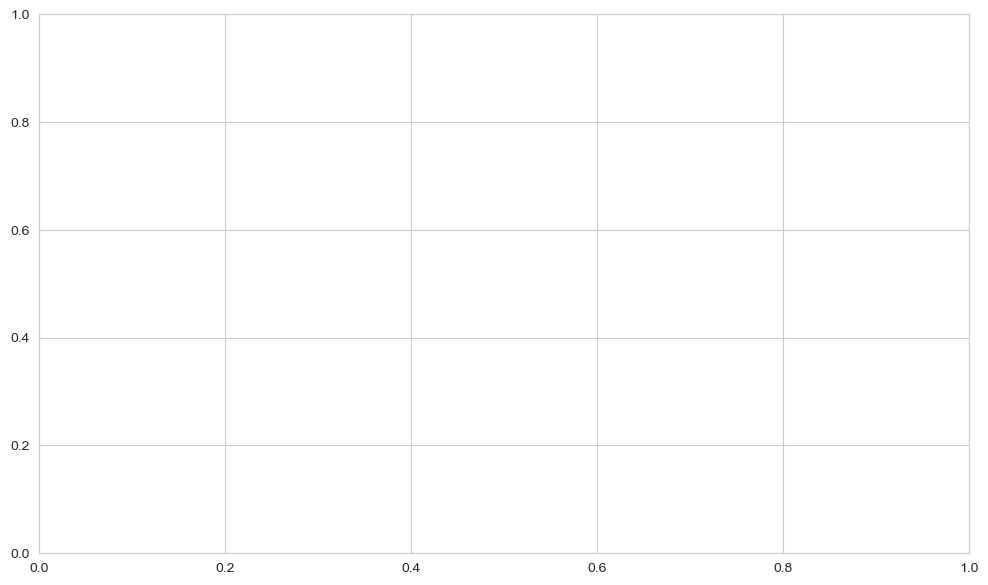

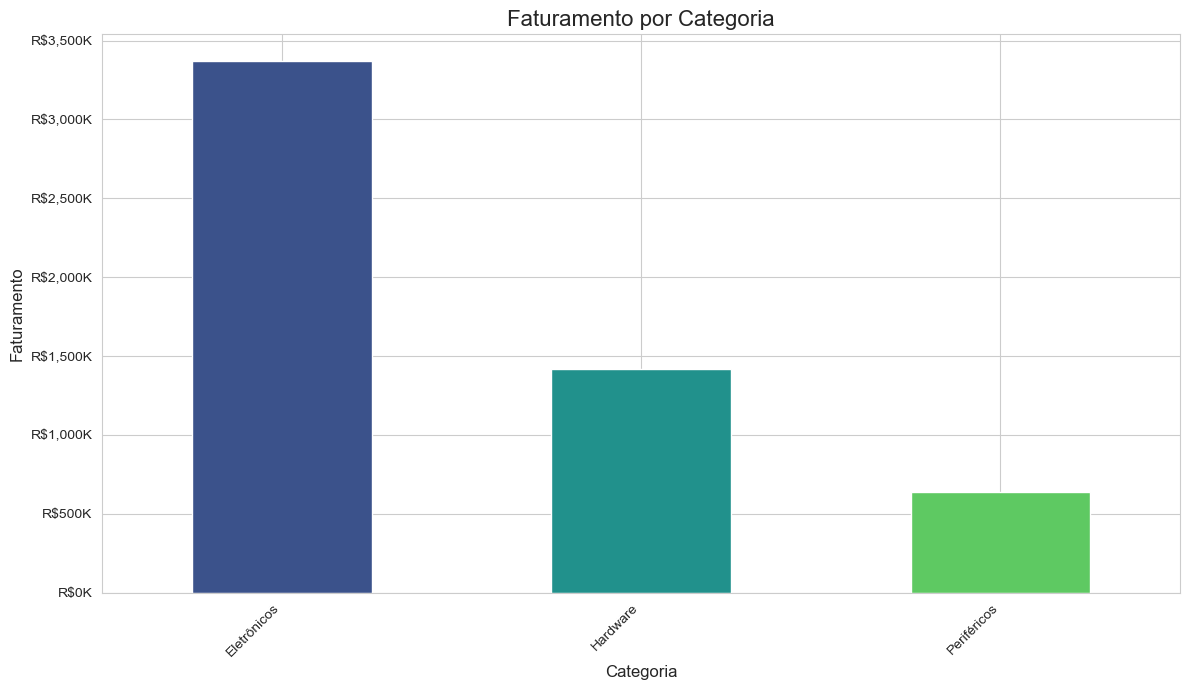

In [69]:
#Importa a funcao FuncFormatter para formatar os eixos
from matplotlib.ticker import FuncFormatter

#Ordena os dados para o grafico ficar mais facil de ler
faturamento_ordenado = faturamento_categoria.sort_values(ascending = False)

#Cria a figura e os Eixos (ax) com plt.subplots()
#Isso nos da mais controle sobre os elementos do grafico.
fig,ax = plt.subplots(figsize =(12,7))

#Cria uma funcao para formatar os numeros
#Isso nos da mais controle sobre os elementos do grafico
fig, ax = plt.subplots(figsize = (12,7))

#Cria uma funcao para formatar os numeros
#Esta funcao recebe um valor 'y' e o transforma em uma string no formato "R$XX K"
def formatador_milhares(y,pos):
    return f'R${y/1000:,.0f}K'

#Cria o objeto formatador
formatter = FuncFormatter(formatador_milhares)

#Aplica o formatador ao eixo y(ax.yaxis)
ax.yaxis.set_major_formatter(formatter)

#Plota os dados usando o objeto 'ax'
faturamento_ordenado.plot(kind = 'bar', ax = ax, color = sns.color_palette("viridis",len(faturamento_ordenado)))

#Adiciona titulos e labels usando 'ax.set...'
ax.set_title('Faturamento por Categoria',fontsize = 16)
ax.set_xlabel('Categoria',fontsize = 12)
ax.set_ylabel('Faturamento',fontsize = 12)

#Ajuista a rotacao dos rotulos do eixo x
plt.xticks(rotation = 45, ha = 'right')

#Garante que tudo fique bem ajustado na imagem final
plt.tight_layout()

#exibe o grafico
plt.show()